In [6]:
# 1. We will use acoustic features to distinguish a male voice from a female. 
# Load the dataset from “voice.csv”, identify the target variable and do a one-hot encoding for the same. 
# Split the dataset into train-test with 20% of the data kept aside for testing. [Hint: Refer to LabelEncoder documentation in scikit-learn] 
# 2. Fit a logistic regression model and measure the accuracy of the test set. [Hint: Refer to Linear Models section in scikit-learn] 
# 3. Compute the correlation matrix that describes the dependence between all predictors and identifies the highly correlated predictors.  
# Plot the correlation matrix using a seaborn heatmap. [Hint: Explore dataframe methods to identify appropriate methods] 
# 4. Based on correlation remove those predictors that are correlated and fit a logistic regression model again and compare the accuracy with that of 
# the previous model. [Hint: Identify correlated variable pairs and remove one among them] 

import seaborn as sns
import matplotlib. pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("voice.csv")
x = df.iloc[:,0:20]   # variables affecting the label - leaving out address and other strings because they may not affect the label
y = df["label"]
label_encoder = LabelEncoder()
encoded_data = label_encoder.fit_transform(y)
y = encoded_data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

C:\Users\SiyaPransh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy :
0.9085173501577287


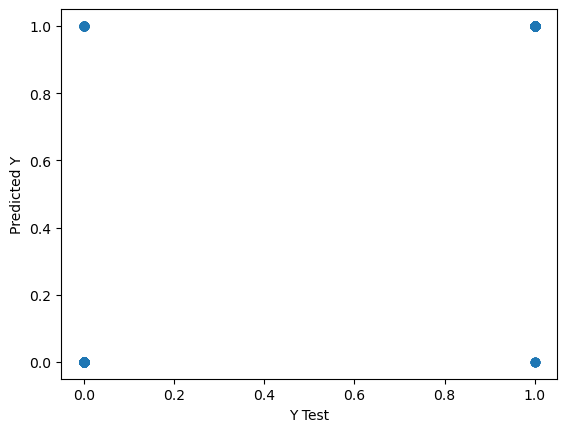

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(x_train, y_train)
pred_y = lr.predict(x_test)
print("Accuracy :")
acc = accuracy_score(y_test,pred_y)
print(acc)

<Figure size 1000x800 with 0 Axes>

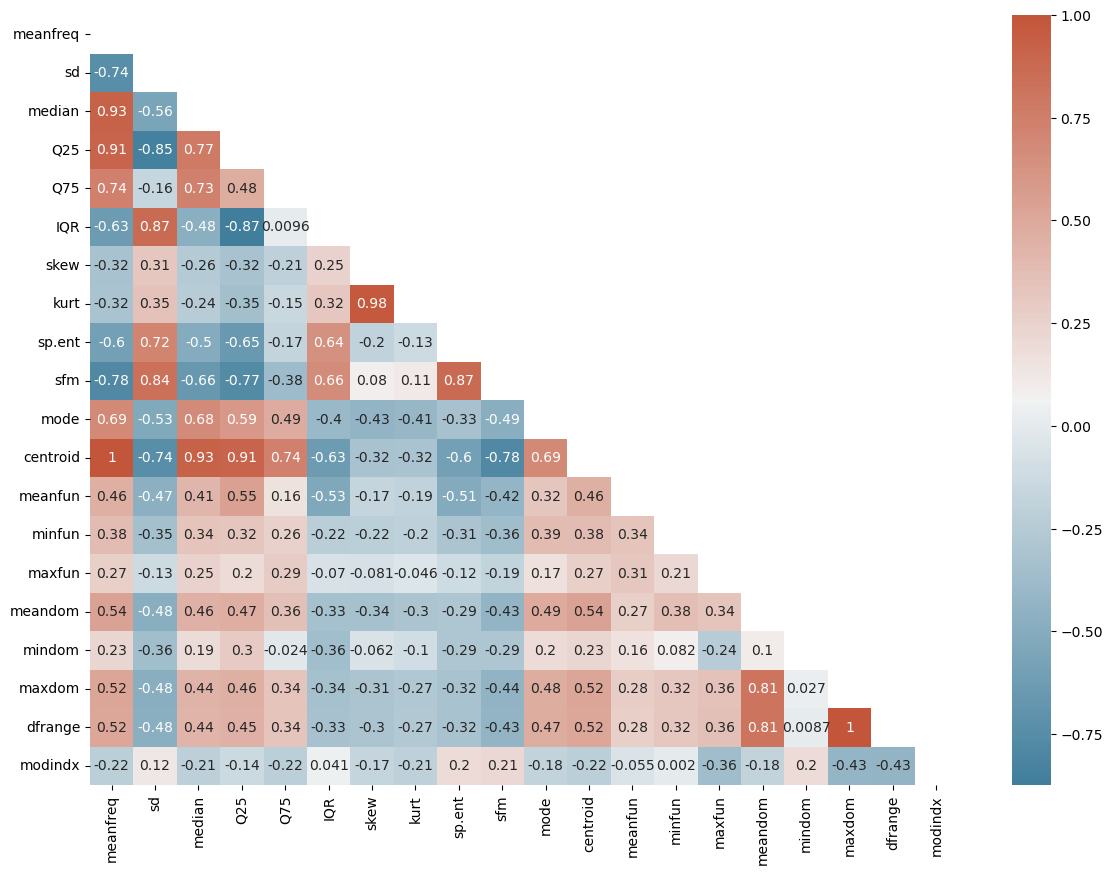

In [16]:
# 3. Compute the correlation matrix that describes the dependence between all predictors and identifies the highly correlated predictors.  
# Plot the correlation matrix using a seaborn heatmap. [Hint: Explore dataframe methods to identify appropriate methods] 
# 4. Based on correlation remove those predictors that are correlated and fit a logistic regression model again and compare the accuracy with that of 
# the previous model. [Hint: Identify correlated variable pairs and remove one among them] 

# Calculate the correlation matrix
import numpy as np
corr = x.corr()

# Create the heatmap
plt.figure(figsize = (10,8))
f, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, cmap = cmap, mask =  mask)
plt.show()